In [6]:
from sklearn.linear_model  import  Lasso
from sklearn.metrics import mean_squared_error

In [10]:
import pandas as pd 
from sklearn.model_selection import train_test_split

In [15]:
insurance_data = pd.read_csv("insurance.csv")

insurance_data["smoker"]= [ 1 if i=='yes' else 0 for i in insurance_data["smoker"]];
#ONE HOT ENCODING
X = insurance_data.drop(columns=["charges"],axis=1);
Y = insurance_data["charges"]
X = pd.get_dummies(X,columns=["region"],drop_first=True,dtype=int) 


insurance_data["smoker"] = [ 1 if i=='yes' else 0 for i in insurance_data["smoker"]];
X["sex"] = [1 if i == 'male' else 0 for i in X["sex"]] 
X["sex"] = [1 if i == 'male' else 0 for i in X["sex"]]


X["bmi_smoker"]= X["smoker"]*X["bmi"]
X["age_smoker"] = X["smoker"]*X["bmi"]


In [16]:
X_train , x_test , Y_train , y_test  = train_test_split(X,Y,
test_size =0.2  ,random_state=42 
)

In [21]:
Lasso_model = Lasso(alpha=0.4)
Lasso_model.fit(X_train,Y_train)

,alpha,0.4
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [22]:
Y_pred = Lasso_model.predict(x_test)

In [23]:
mean_s_err = mean_squared_error(Y_pred,y_test)

In [24]:
print(f"MSE : alpha = {a}",mean_s_err)

20957891.98501558

In [27]:
r2

0.850389685388596

In [39]:
alpha = [0.0001,0.002,0.01,0.1 ,0.5 , 1, 2, 4, 5 ,6 ,7 ,10 , 15 , 20 , 30 , 50  ]
mse = []
for a in alpha :
        Lasso_model = Lasso(alpha=a)
        Lasso_model.fit(X_train,Y_train)
        Y_pred = Lasso_model.predict(x_test)
        mean_s_err = mean_squared_error(Y_pred,y_test)
        print(f"MSE : alpha = {a}",mean_s_err)
        mse.append(mean_s_err)
        

MSE : alpha = 0.0001 20960037.67597471
MSE : alpha = 0.002 20960027.29773452
MSE : alpha = 0.01 20959983.60246152
MSE : alpha = 0.1 20959493.750283007
MSE : alpha = 0.5 20957366.681825537
MSE : alpha = 1 20954829.86740546
MSE : alpha = 2 20950129.53214342
MSE : alpha = 4 20942269.100385673
MSE : alpha = 5 20939101.829991747
MSE : alpha = 6 20936483.15001413
MSE : alpha = 7 20934350.295568656
MSE : alpha = 10 20931108.96294721
MSE : alpha = 15 20935897.075765375
MSE : alpha = 20 20952747.11595733
MSE : alpha = 30 21022654.082800332
MSE : alpha = 50 21281787.428275973


<Axes: >

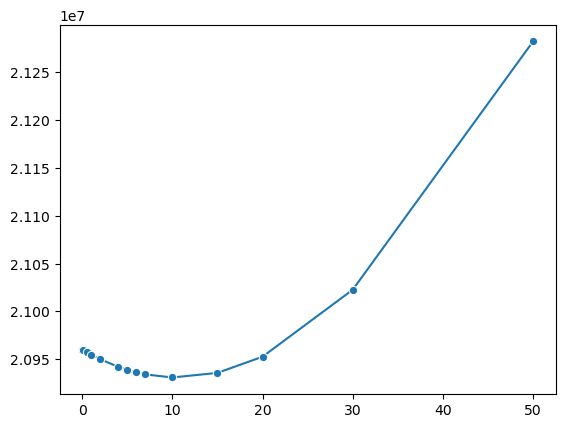

In [40]:
import seaborn as sns 
sns.lineplot(x=alpha , y=mse , marker='o')

In [59]:
Lasso_model = Lasso(alpha=9.8)
Lasso_model.fit(X_train,Y_train)
Y_pred = Lasso_model.predict(x_test)
mean_s_err = mean_squared_error(Y_pred,y_test)
print(f"MSE : alpha = {10}",mean_s_err)
mse.append(mean_s_err)

MSE : alpha = 10 20931167.893774074


In [60]:
from sklearn.metrics import r2_score 

In [61]:
r2 = r2_score(Y_pred,y_test)

In [62]:
r2

0.8495933111527654

In [63]:
from sklearn.linear_model import LassoCV

In [75]:
alpha = [0.0001,0.002,0.01, 0.2,0.1,0.3,0.35 ,0.4,0.5 , 1, 2, 4, 5 ,6 ,7 ,10 , 15 , 20 , 30 , 50  ]
lasso_model = LassoCV(
    alphas = alpha ,
    random_state = 42 , 
    cv = 5 
)
lasso_model.fit(X_train,Y_train)

,eps,0.001
,n_alphas,'deprecated'
,alphas,"[0.0001, 0.002, ...]"
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,copy_X,True
,cv,5
,verbose,False
,n_jobs,None


In [76]:
print("Best aplha value : " , lasso_model.alpha_)

Best aplha value :  0.3


In [77]:
Y_pred = lasso_model.predict(x_test)

In [80]:
r2_lasso = r2_score(y_test,Y_pred)

In [81]:
r2_lasso

0.8650010231280854

In [ ]:
print("recall score: ", recall_score(y_test, y_pred))
print("accuracy score:", accuracy_score(y_test, y_pred))
print("precision score: ", precision_score(y_test, y_pred))